# Práctica ML y DL - 02 Modelado
En este notebook probaremos diversos modelos de simulación basados en árboles y AutoML:
1. `Custom Decision Tree` (Árbol de Decisión individual)
2. `RandomForestRegressor` (Bagging)
3. `GradientBoostingRegressor` (Boosting clásico)
4. `XGBRegressor` (Extreme Gradient Boosting)
5. `LGBMRegressor` (Light Gradient Boosting)
6. `AutoGluon` (AutoML de nueva generación que entrena y emsambla múltiples modelos potentes automáticamente)

Aplicaremos One-Hot Encoding a las variables categóricas, usaremos `GridSearchCV` para buscar hiperparámetros óptimos y evaluaremos a través de validación el rendimiento de los modelos.
También **imprimiremos/graficaremos internamente la estructura de un Árbol de Decisión** para que la lógica de negocio resulte totalmente explicable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# Inicializar SHAP javascript
shap.initjs()

# Configuración de los gráficos
plt.style.use('ggplot')
sns.set_palette("husl")

# Cargar los datos curados
df = pd.read_csv('data/processed_train_data.csv')
print("Dimensiones Datos Procesados:", df.shape)

# Transformar la altitud a variable continua explícitamente
df['ALTITUD'] = df['ALTITUD'].astype(float)

Dimensiones Datos Procesados: (8526, 18)


## 1. One-Hot Encoding e Imputación Final
Aplicamos variables dummy (One-Hot Encoding) a las variables categóricas evidentes en nuestro dataset.

In [2]:
# Excluimos 2022 si existiera
df = df[df['CAMPAÑA'] != 22]

categorical_cols = ['ID_ZONA', 'ID_ESTACION', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR']

# Convertirlas a string temporalmente para que get_dummies actue sobre ellas
for col in categorical_cols:
    df[col] = df[col].astype(str)

# Hacemos el OHE
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separamos Train Histórico (<= 2020) y Test (2021)
df_historico = df_encoded[df_encoded['CAMPAÑA'] <= 20].copy()
df_test = df_encoded[df_encoded['CAMPAÑA'] == 21].copy()

# Eliminar nulos en la variable objetivo del train histórico
df_historico.dropna(subset=['PRODUCCION'], inplace=True)

# Guardamos el X_test_output sin encode para recrear Mi_Solucion.txt según los ids originales
df_test_unencoded = df[df['CAMPAÑA'] == 21].copy()
X_test_output = df_test_unencoded[['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']].copy()

# Features y Target totales
X_full = df_historico.drop(columns=['PRODUCCION'])
y_full = df_historico['PRODUCCION']

X_test_2021 = df_test.drop(columns=['PRODUCCION'])

# Alineamos las columnas de test con train
X_test_2021 = X_test_2021.reindex(columns=X_full.columns, fill_value=0)

# Split de validación (80% / 20%) 
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
print("Tamaño del set de entrenamiento para búsqueda/evaluación OHE:", X_train.shape)
print("Tamaño del set de validación para evaluación final OHE:", X_val.shape)

Tamaño del set de entrenamiento para búsqueda/evaluación OHE: (5985, 180)
Tamaño del set de validación para evaluación final OHE: (1497, 180)


## 2. Visualización e Interpretabilidad: El Árbol de Decisión
Antes de ensayar con múltiples estimadores complejos (Random Forest / Boostings), resulta muy útil crear un modelo base compuesto por un **único Árbol de Decisión** y graficarlo. Esto nos permite entender qué reglas biológicas/físicas sigue la matemática de fondo para separar las producciones.
Lo limitaremos a `max_depth=3` puramente para que la gráfica resultante sea legible.

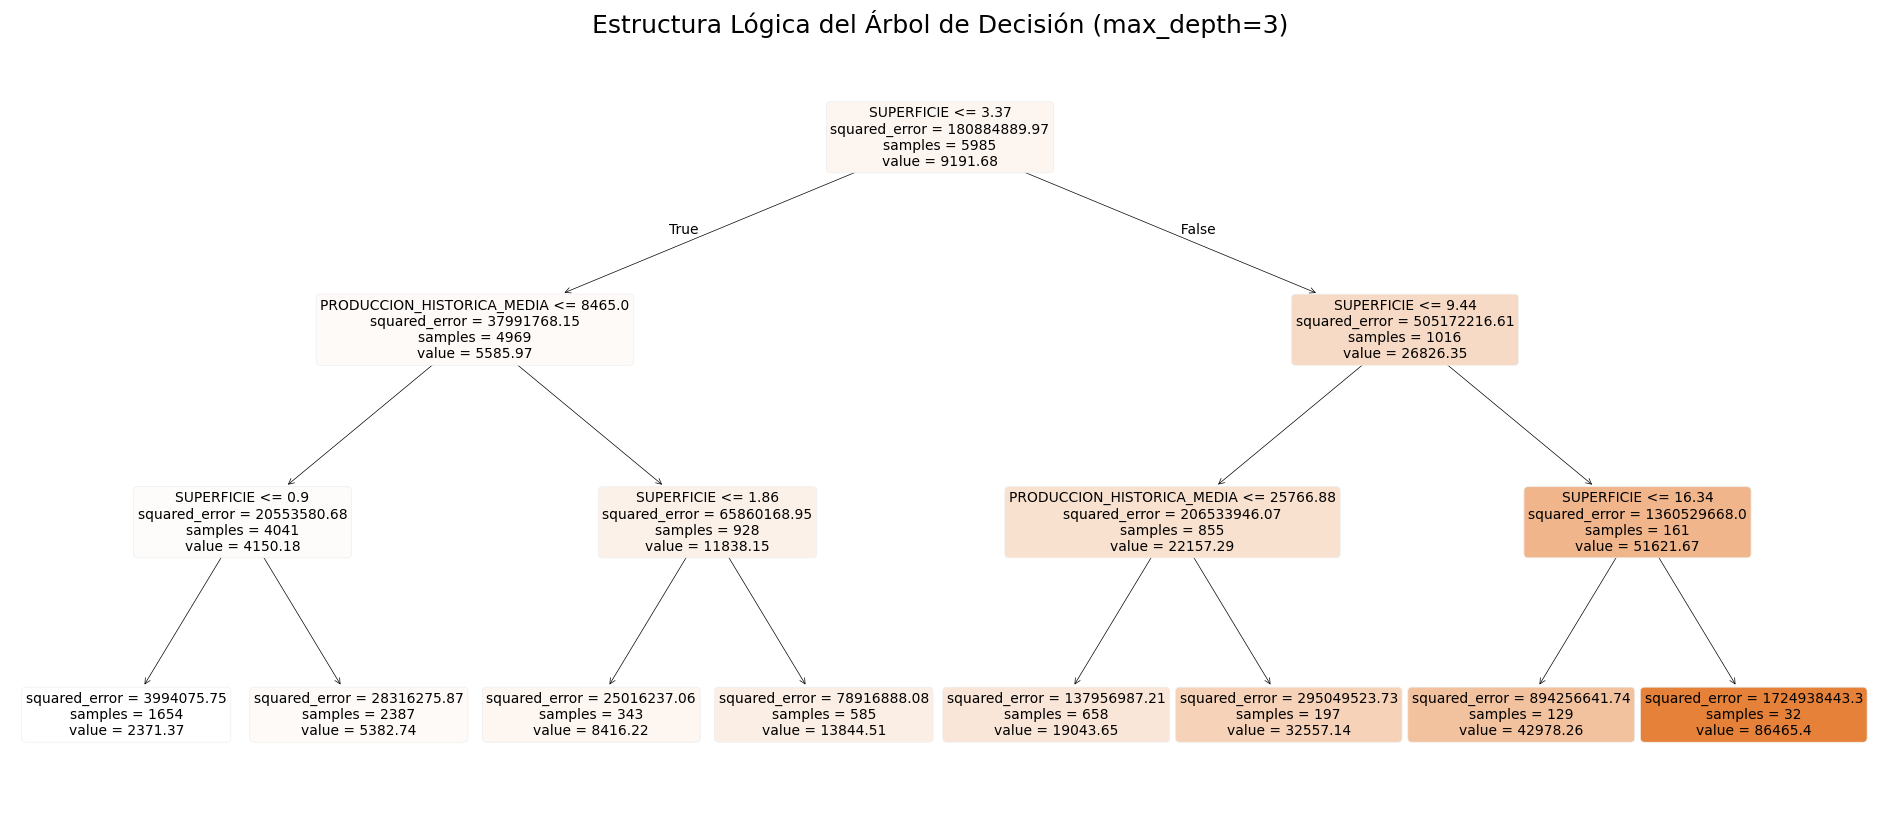

In [3]:
tree_visual = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_visual.fit(X_train, y_train)

plt.figure(figsize=(24, 10))
plot_tree(tree_visual, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)
plt.title("Estructura Lógica del Árbol de Decisión (max_depth=3)", fontsize=18)
plt.show()

## 3. Búsqueda de Hiperparámetros Exhaustiva (GridSearchCV) para 5 Modelos
Para comprobar empíricamente cuál es la técnica dominante, vamos a optimizar las métricas introduciendo también un Árbol de decisión simple (`DecisionTreeRegressor`) y el `GradientBoostingRegressor` clásico de Scikit-Learn.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

score_rmse = make_scorer(rmse, greater_is_better=False)

param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [10, 15]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6]
}

param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

param_grid_lgb = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1]
}

param_grid_cb = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3, 5]
}

# --- CatBoost ---
cb = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0
)

# Declaramos Búsquedas

search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=param_grid_dt, cv=3, scoring=score_rmse, n_jobs=-1)
search_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_rf, cv=3, scoring=score_rmse, n_jobs=-1)
search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid=param_grid_gb, cv=3, scoring=score_rmse, n_jobs=-1)
search_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_xgb, cv=3, scoring=score_rmse, n_jobs=-1)
search_lgb = GridSearchCV(LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), param_grid=param_grid_lgb, cv=3, scoring=score_rmse, n_jobs=-1)
search_cb = GridSearchCV(
    cb,
    param_grid_cb,
    scoring=score_rmse,
    cv=3,
    n_jobs=-1
)

print("Buscando hiperparámetros...")
search_dt.fit(X_train, y_train)
search_rf.fit(X_train, y_train)
search_gb.fit(X_train, y_train)
search_xgb.fit(X_train, y_train)
search_lgb.fit(X_train, y_train)
search_cb.fit(X_train, y_train)

best_dt = search_dt.best_estimator_
best_rf = search_rf.best_estimator_
best_gb = search_gb.best_estimator_
best_xgb = search_xgb.best_estimator_
best_lgb = search_lgb.best_estimator_
best_cb = search_cb.best_estimator_

print("\nMejores hiperparámetros encontrados en validación cruzada:")
print("- Decision Tree:", search_dt.best_params_)
print("- Random Forest:", search_rf.best_params_)
print("- Gradient Boosting:", search_gb.best_params_)
print("- XGBoost:", search_xgb.best_params_)
print("- LightGBM:", search_lgb.best_params_)
print("- CatBoost:", search_cb.best_params_)

Buscando hiperparámetros...

Mejores hiperparámetros encontrados en validación cruzada:
- Decision Tree: {'max_depth': 5, 'min_samples_split': 10}
- Random Forest: {'max_depth': 15, 'n_estimators': 300}
- Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
- XGBoost: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
- LightGBM: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 100}
- CatBoost: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 5, 'learning_rate': 0.1}


## 4. Visualización Avanzada (Learning Curves y Feature Importance)

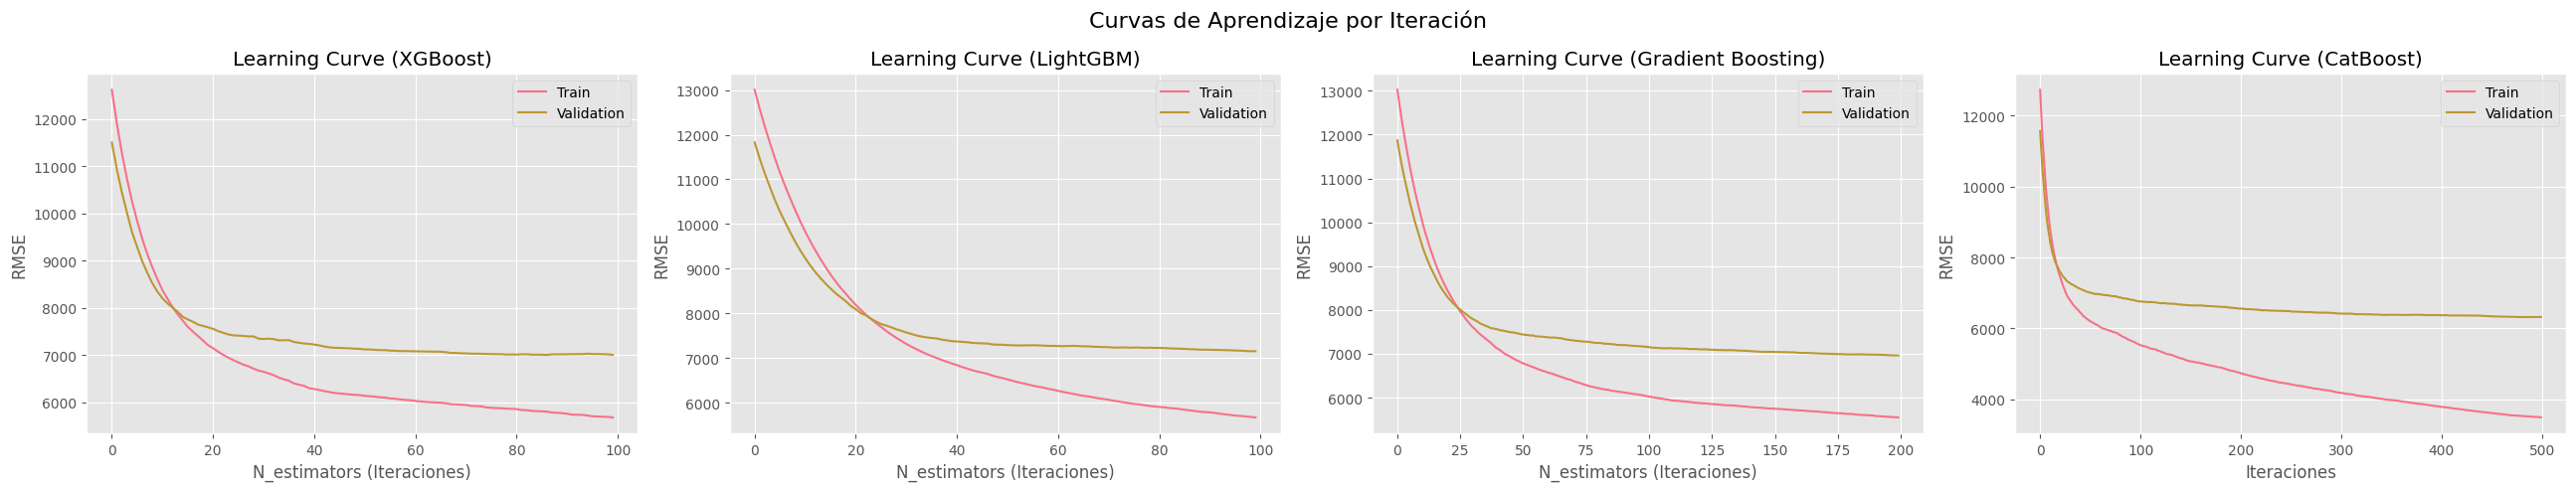

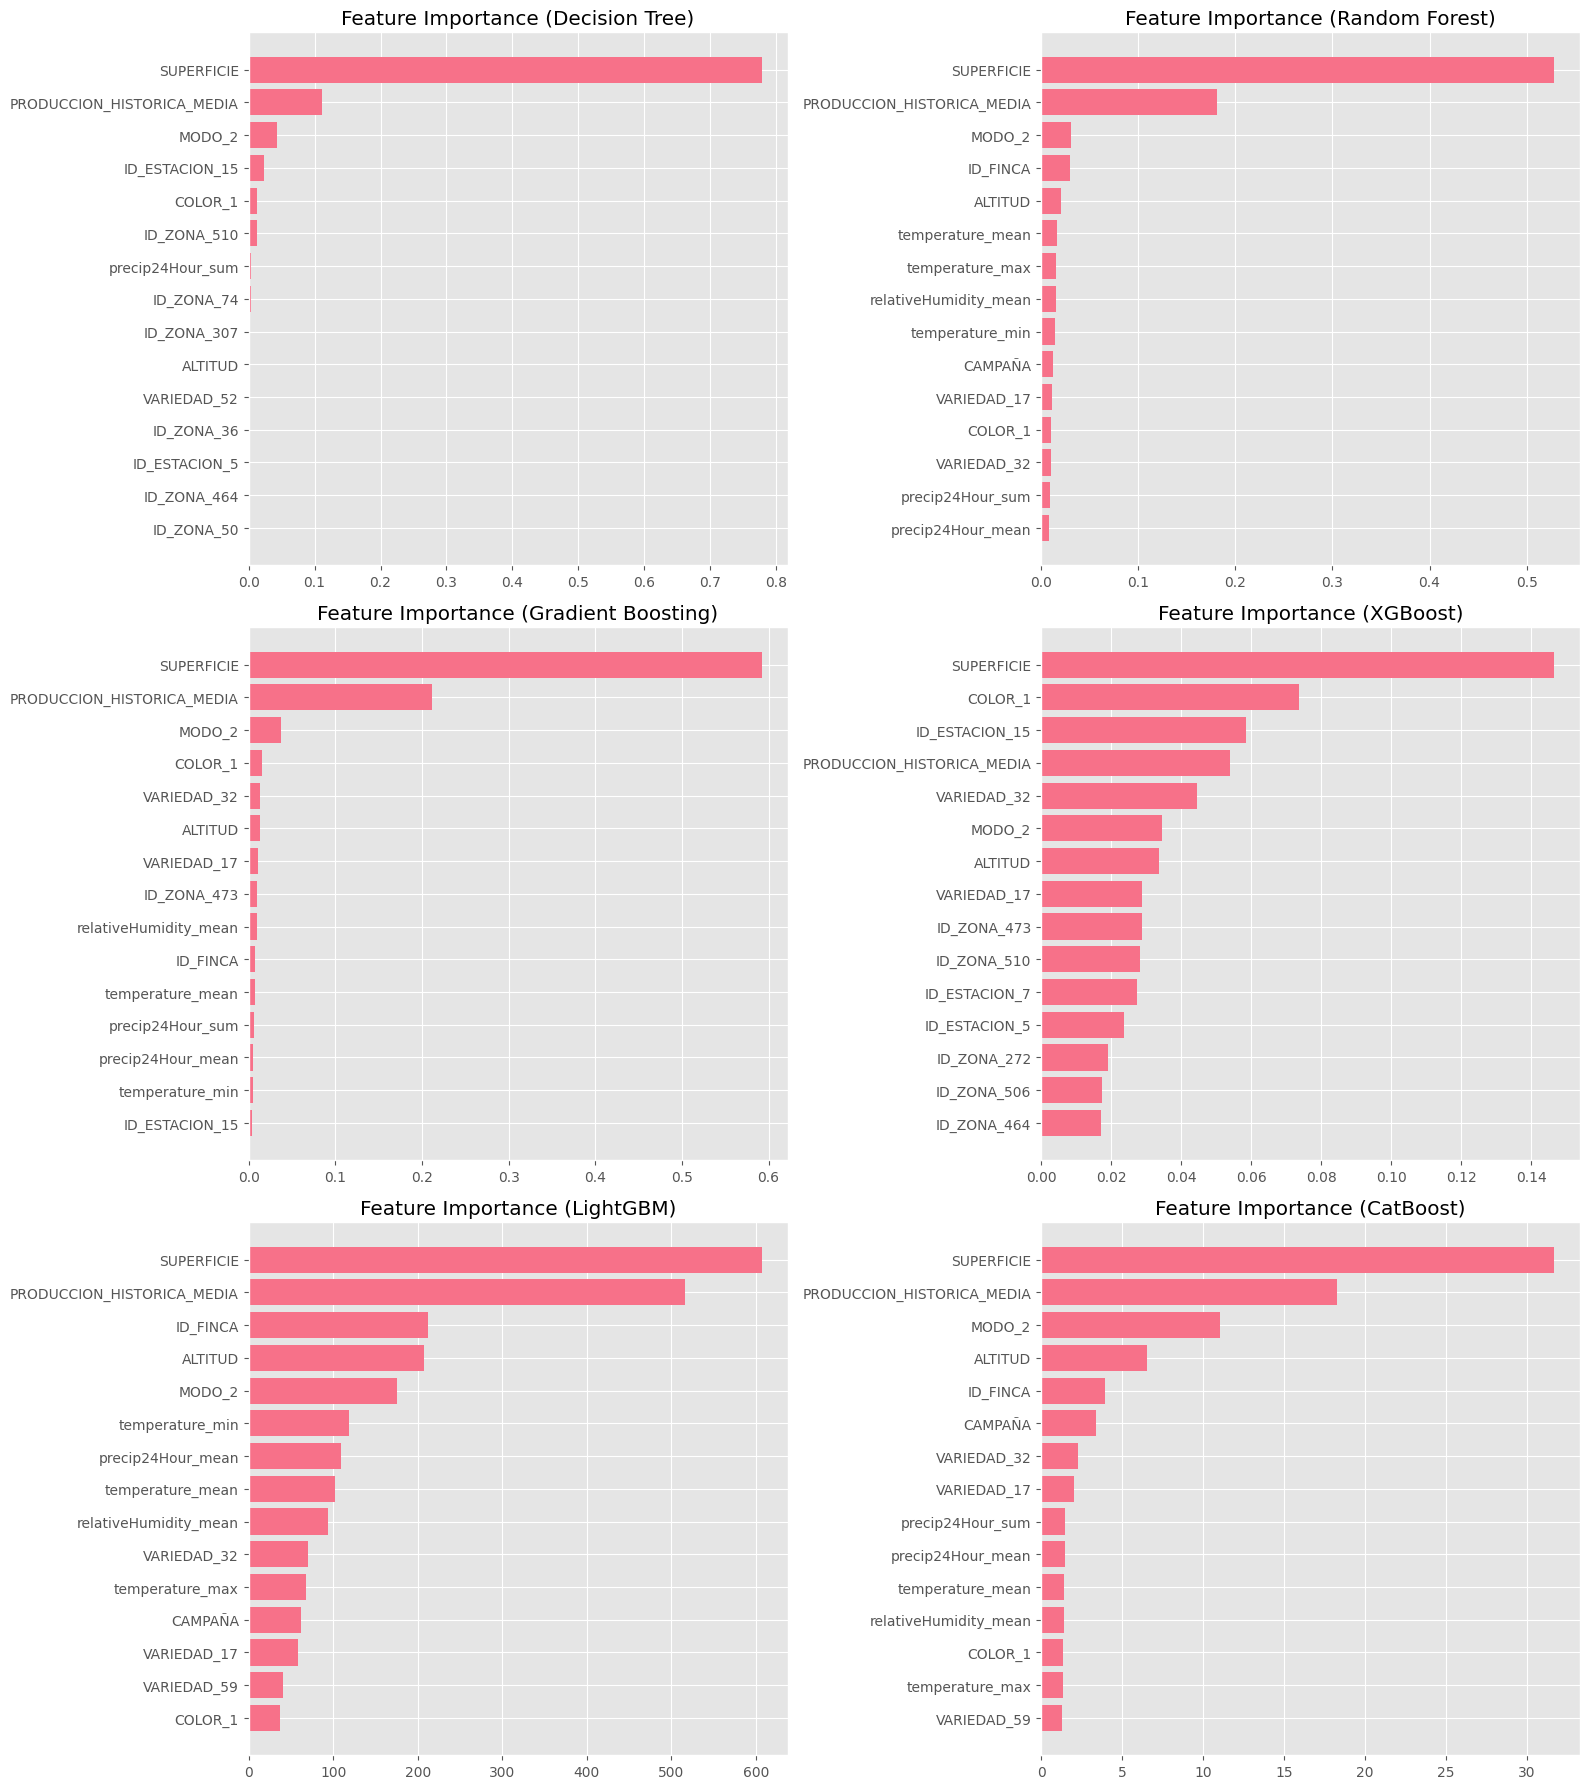

In [5]:
# --- Curvas de Aprendizaje (Learning Curves) para los cuatro modelos de Boosting ---
fig, axes = plt.subplots(1, 4, figsize=(26, 5))

# 1. XGBoost
xgb_eval = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
xgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
resultados_xgb = xgb_eval.evals_result_

epochs_xgb = len(resultados_xgb['validation_0']['rmse'])
x_axis_xgb = range(0, epochs_xgb)
axes[0].plot(x_axis_xgb, resultados_xgb['validation_0']['rmse'], label='Train')
axes[0].plot(x_axis_xgb, resultados_xgb['validation_1']['rmse'], label='Validation')
axes[0].legend()
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('N_estimators (Iteraciones)')
axes[0].set_title('Learning Curve (XGBoost)')

# 2. LightGBM
lgb_eval = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)
lgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])
resultados_lgb = lgb_eval.evals_result_

epochs_lgb = len(resultados_lgb['training']['l2'])
x_axis_lgb = range(0, epochs_lgb)
# LightGBM devuelve L2 (MSE), por lo que aplicamos np.sqrt para comparar con RMSE
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['training']['l2']), label='Train')
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['valid_1']['l2']), label='Validation')
axes[1].legend()
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('N_estimators (Iteraciones)')
axes[1].set_title('Learning Curve (LightGBM)')

# 3. Gradient Boosting Clásico (Scikit-Learn)
# Scikit-learn no usa eval_set por defecto, pero guarda el historial del 'train' en train_score_ y
# ofrece staged_predict() para calcular el validation.
train_score_gb = np.zeros((search_gb.best_params_['n_estimators'],), dtype=np.float64)
val_score_gb = np.zeros((search_gb.best_params_['n_estimators'],), dtype=np.float64)

for i, y_pred in enumerate(best_gb.staged_predict(X_train)):
    train_score_gb[i] = rmse(y_train, y_pred)

for i, y_pred in enumerate(best_gb.staged_predict(X_val)):
    val_score_gb[i] = rmse(y_val, y_pred)

x_axis_gb = range(0, search_gb.best_params_['n_estimators'])
axes[2].plot(x_axis_gb, train_score_gb, label='Train')
axes[2].plot(x_axis_gb, val_score_gb, label='Validation')
axes[2].legend()
axes[2].set_ylabel('RMSE')
axes[2].set_xlabel('N_estimators (Iteraciones)')
axes[2].set_title('Learning Curve (Gradient Boosting)')

# 4. CatBoost — usa su propio eval_set nativo con log interno
cb_eval = CatBoostRegressor(**search_cb.best_params_, loss_function='RMSE', random_state=42, verbose=0)
cb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])

cb_train_rmse = cb_eval.get_evals_result()['learn']['RMSE']
cb_val_rmse   = cb_eval.get_evals_result()['validation_1']['RMSE']
x_axis_cb = range(len(cb_train_rmse))
axes[3].plot(x_axis_cb, cb_train_rmse, label='Train')
axes[3].plot(x_axis_cb, cb_val_rmse,   label='Validation')
axes[3].legend()
axes[3].set_ylabel('RMSE')
axes[3].set_xlabel('Iteraciones')
axes[3].set_title('Learning Curve (CatBoost)')

plt.suptitle("Curvas de Aprendizaje por Iteración", fontsize=16)
plt.tight_layout()
plt.show()

# --- Feature Importance para TODOS los modelos (excepto ensamblados o AutoML puro) ---

# Preparamos una lista con los modelos que pueden darnos feature importance nativa
modelos_con_importancia = {
    'Decision Tree': best_dt,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cb,
}

# Calculamos cuantas filas necesitaremos (2 plots por fila)
n_modelos = len(modelos_con_importancia)
columnas = 2
filas = int(np.ceil(n_modelos / columnas))

fig, axes = plt.subplots(filas, columnas, figsize=(16, 6 * filas))
axes = axes.flatten()  # Aplanamos el array de 2D a 1D para iterar mas facil

def plot_importance(model, title, ax):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.zeros(len(X_train.columns))

    # Mostrar solo el top 15 de features más importantes
    indices = np.argsort(importances)[-15:]
    ax.barh(range(len(indices)), importances[indices], align='center')
    ax.set_yticks(range(len(indices)), [X_train.columns[i] for i in indices])
    ax.set_title(title)

# Iteramos sobre nuestro diccionario
for i, (nombre, modelo) in enumerate(modelos_con_importancia.items()):
    plot_importance(modelo, f'Feature Importance ({nombre})', axes[i])

# Si tenemos un número impar de gráficos, oculta el último eje vacío
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 4.5 AutoGluon AutoML
Autogluon es un framework avanzado que abstrae todo el pipeline de modelado entrenando automáticamente decenas de modelos potentes (incluyendo combinaciones, apilados, redes neuronales, etc.).

In [6]:
# Es importante asegurar la variable objetivo y juntar X e y por exigencias de Autogluon
import warnings
warnings.filterwarnings('ignore')

try:
    from autogluon.tabular import TabularPredictor
    
    # AutoGluon necesita el dataframe completo (Features + Target)
    df_ag_train = X_train.copy()
    df_ag_train['PRODUCCION'] = y_train
    
    df_ag_val = X_val.copy()
    df_ag_val['PRODUCCION'] = y_val
    
    # Capa única (sin bagging ni stacking) + solo modelos de árbol para que acabe en ~60 s.
    # Las redes neuronales (NeuralNetFastAI, NeuralNetTorch) son las que disparan el tiempo,
    # por eso las excluimos explícitamente con excluded_model_types.
    predictor = TabularPredictor(label='PRODUCCION', eval_metric='root_mean_squared_error').fit(
        train_data=df_ag_train,
        tuning_data=df_ag_val,
        time_limit=120,
        presets='medium_quality',
        num_bag_folds=0,
        num_stack_levels=0,
        excluded_model_types=['NN_TORCH', 'FASTAI'],
    )
    
    # Leaderboard de los mejores modelos internamente hallados por AutoGluon
    print("\n--- Leaderboard de AutoGluon ---")
    leaderboard = predictor.leaderboard(df_ag_val)
    
    # Extraemos predicciones
    ag_preds = predictor.predict(X_val)
    print(f"AutoGluon Validation RMSE: {rmse(y_val, ag_preds)}")
    
    # Añadimos sus predicciones al DataFrame global del ensamble
    # (Aseguramos que los diccionarios globales estén inicializados para no perder la info)
    if 'predicciones_val' not in globals():
        predicciones_val = {}
    if 'modelos_sintonizados' not in globals():
        modelos_sintonizados = {}
        
    predicciones_val['AutoGluon'] = ag_preds
    modelos_sintonizados['AutoGluon'] = predictor
    
except ImportError:
    print("AutoGluon no está instalado en este entorno. Usa: pip install autogluon")



No path specified. Models will be saved in: "AutogluonModels/ag-20260310_170055"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Darwin
Platform Machine:   arm64
Platform Version:   Darwin Kernel Version 25.3.0: Wed Jan 28 20:49:24 PST 2026; root:xnu-12377.81.4~5/RELEASE_ARM64_T8132
CPU Count:          10
Pytorch Version:    2.9.1
CUDA Version:       CUDA is not available
GPU Count:          WARNING: Exception was raised when calculating GPU count (AssertionError)
Memory Avail:       4.27 GB / 24.00 GB (17.8%)
Disk Space Avail:   360.08 GB / 926.35 GB (38.9%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "/Users/alexstoia/Library/CloudStorage/OneDrive-FundaciónUniversitariaSanPabloCEU/AprendizajeAutomaticoYDeepLearning/PFinal/AutogluonModels/ag-202603

[1000]	valid_set's rmse: 6697.67
[2000]	valid_set's rmse: 6642.17
[3000]	valid_set's rmse: 6609.51
[4000]	valid_set's rmse: 6606.01


	-6600.364	 = Validation score   (-root_mean_squared_error)
	16.08s	 = Training   runtime
	0.07s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 103.67s of the 103.67s of remaining time.
	Fitting with cpus=10, gpus=0, mem=0.1/4.2 GB


[1000]	valid_set's rmse: 6989.89


	-6979.2171	 = Validation score   (-root_mean_squared_error)
	4.17s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 99.46s of the 99.46s of remaining time.
	Fitting with cpus=10, gpus=0, mem=0.0/4.2 GB
	-6839.8476	 = Validation score   (-root_mean_squared_error)
	2.47s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 96.87s of the 96.87s of remaining time.
	Fitting with cpus=10, gpus=0
	-6208.1421	 = Validation score   (-root_mean_squared_error)
	20.62s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 76.22s of the 76.22s of remaining time.
	Fitting with cpus=10, gpus=0, mem=0.0/4.4 GB
	-6516.3512	 = Validation score   (-root_mean_squared_error)
	1.5s	 = Training   runtime
	0.03s	 = Validation runtime
Fitting model: XGBoost ... Training model for up to 74.60s of the 74.60s of remaining time.
	Fitting with cpus=

[1000]	valid_set's rmse: 6522.23
[2000]	valid_set's rmse: 6518.44


	-6517.2478	 = Validation score   (-root_mean_squared_error)
	29.78s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: WeightedEnsemble_L2 ... Training model for up to 119.88s of the 42.95s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=10, gpus=0, mem=0.0/4.7 GB
	Ensemble Weights: {'CatBoost': 0.625, 'ExtraTreesMSE': 0.188, 'LightGBMLarge': 0.125, 'XGBoost': 0.062}
	-6146.4393	 = Validation score   (-root_mean_squared_error)
	0.01s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 77.09s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 16032.1 rows/s (1497 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("/Users/alexstoia/Library/CloudStorage/OneDrive-FundaciónUniversitariaSanPabloCEU/AprendizajeAutomaticoYDeepLearning/PFinal/AutogluonModels/ag-20260310_170055")



--- Leaderboard de AutoGluon ---
AutoGluon Validation RMSE: 6146.439292574703


These features in provided data are not utilized by the predictor and will be ignored: ['ID_ZONA_515', 'ID_ZONA_62', 'ID_ZONA_639', 'ID_ZONA_71', 'ID_ZONA_734', 'ID_ZONA_772', 'ID_ZONA_816', 'ID_ZONA_836', 'ID_ZONA_848', 'ID_ESTACION_1', 'ID_ESTACION_11', 'ID_ESTACION_13', 'ID_ESTACION_17', 'ID_ESTACION_4', 'ID_ESTACION_6']
Computing feature importance via permutation shuffling for 165 features using 1497 rows with 5 shuffle sets...
	146.99s	= Expected runtime (29.4s per shuffle set)


Calculando Permutation Feature Importance para AutoGluon (puede tardar un momento)...


	44.91s	= Actual runtime (Completed 5 of 5 shuffle sets)


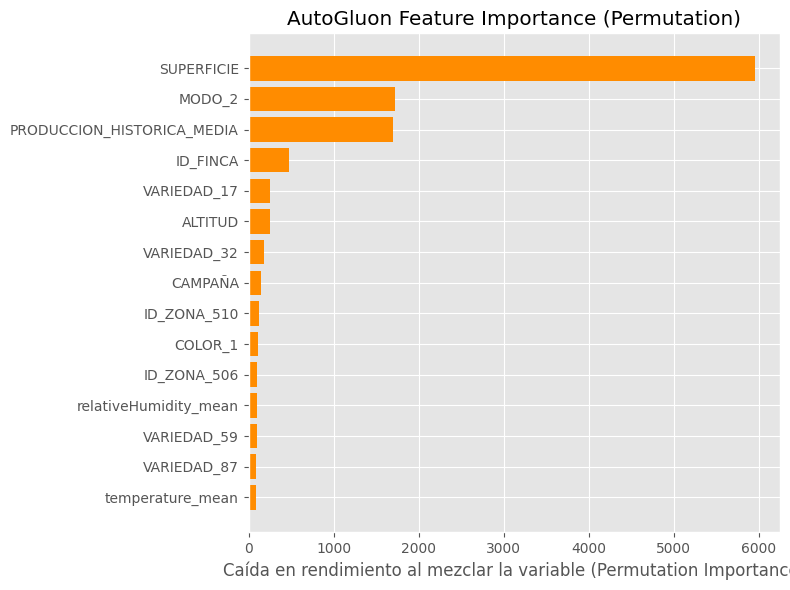

Resumen numérico de la importancia en AutoGluon:


,importance,stddev,p_value,n,p99_high,p99_low
SUPERFICIE,5949.770012,346.120403,1.368145e-06,5,6662.436706,5237.103318
MODO_2,1718.988782,212.607020,2.751649e-05,5,2156.749575,1281.227990
PRODUCCION_HISTORICA_MEDIA,1692.169913,58.969128,1.766857e-07,5,1813.588163,1570.751664
ID_FINCA,473.341143,53.496667,1.924999e-05,5,583.491519,363.190766
VARIEDAD_17,251.615276,39.577320,7.109292e-05,5,333.105526,170.125026
ALTITUD,246.231343,75.984522,9.626843e-04,5,402.684524,89.778161
VARIEDAD_32,176.372019,54.704368,9.812965e-04,5,289.009070,63.734969
CAMPAÑA,142.141105,50.010402,1.570576e-03,5,245.113214,39.168995
ID_ZONA_510,117.926420,58.761236,5.463343e-03,5,238.916617,-3.063777
COLOR_1,107.406651,38.332140,1.655512e-03,5,186.333057,28.480244


In [7]:
# --- Feature Importance para AutoGluon (Permutation Importance) ---
if 'AutoGluon' in modelos_sintonizados:
    print("Calculando Permutation Feature Importance para AutoGluon (puede tardar un momento)...")
    
    ag_predictor_final = modelos_sintonizados['AutoGluon']
    
    # Necesitamos el dataframe de validación unido con su target como lo necesita AutoGluon
    df_ag_val = X_val.copy()
    df_ag_val['PRODUCCION'] = y_val
    
    # Calculamos la métrica de feature importance interno de autogluon
    ag_importance = ag_predictor_final.feature_importance(df_ag_val)
    
    # El resultado de AutoGluon es un DataFrame ordenado por importancia. 
    # Extraemos las 15 variables más importantes
    top_15_ag = ag_importance.head(15).sort_values(by='importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # Usamos el campo 'importance' del DataFrame resultante
    ax.barh(top_15_ag.index, top_15_ag['importance'], align='center', color='darkorange')
    ax.set_title('AutoGluon Feature Importance (Permutation)')
    ax.set_xlabel('Caída en rendimiento al mezclar la variable (Permutation Importance)')
    
    plt.tight_layout()
    plt.show()
    
    print("Resumen numérico de la importancia en AutoGluon:")
    display(ag_importance.head(10))
else:
    print("AutoGluon no está en el diccionario de modelos. Asegúrate de haberlo entrenado.")


## 5. Analisis SHAP (LightGBM)
Usaremos valores **SHAP** sobre el mejor ajuste de LightGBM para interpretar en qué dirección influyen las variables.

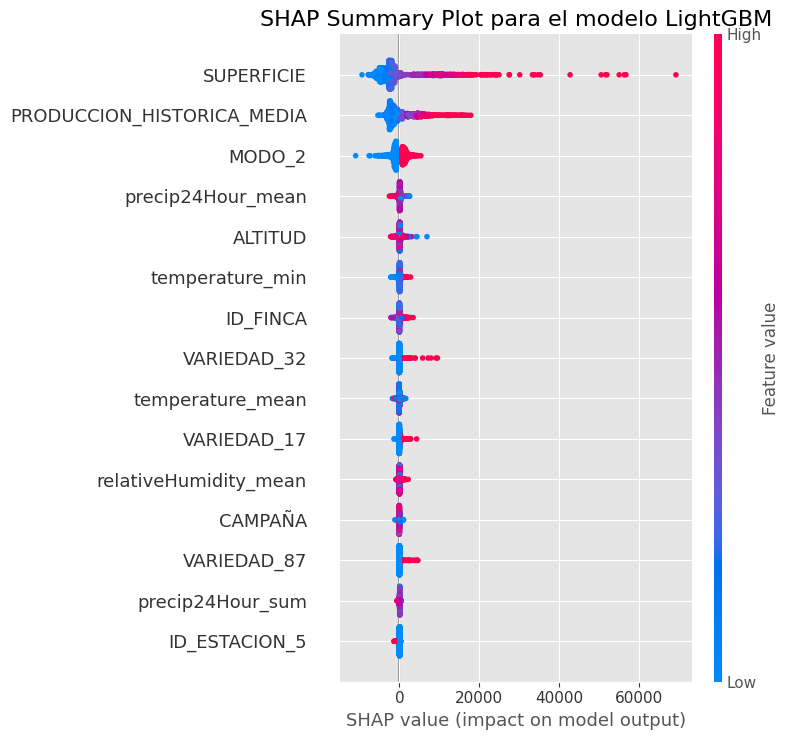

In [8]:
# Calcular SHAP values en la validación
explainer = shap.Explainer(best_lgb)
shap_values = explainer(X_val)

# El summary plot estándar con los "colores" reflejando impacto direccional
plt.figure(figsize=(10,6))
plt.title("SHAP Summary Plot para el modelo LightGBM", fontsize=16)
shap.summary_plot(shap_values, X_val, max_display=15)
plt.show()

## 6. Evaluación de Modelos y Ensamblado Final
Evaluamos los **seis modelos** en el set de validación e introducimos el `VotingRegressor`, integrando los algoritmos de ensamblado más estables (RandomForest, GBM, XGB, LGB, **CatBoost**).

In [9]:
# Actualizar el diccionario evitando borrar AutoGluon si ya existe
if 'modelos_sintonizados' not in locals():
    modelos_sintonizados = {}
modelos_sintonizados.update({
    'Decision Tree': best_dt,
    'Gradient Boosting': best_gb,
    'RandomForest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cb,
})

resultados = []
if 'predicciones_val' not in locals():
    predicciones_val = {}

# Recorremos los modelos para añadirlos a los resultados
for nombre, modelo in modelos_sintonizados.items():
    # AutoGluon se evaluó en su propia celda y no usa el predict tradicional de scikit
    if nombre == 'AutoGluon':
        if 'AutoGluon' in predicciones_val:
            preds = predicciones_val['AutoGluon']
            resultados.append({
                'Modelo': nombre,
                'RMSE': rmse(y_val, preds),
                'MAE': mean_absolute_error(y_val, preds),
                'R2': r2_score(y_val, preds)
            })
        continue

    preds = modelo.predict(X_val)
    preds = np.maximum(preds, 0)
    predicciones_val[nombre] = preds

    resultados.append({
        'Modelo': nombre,
        'RMSE': rmse(y_val, preds),
        'MAE': mean_absolute_error(y_val, preds),
        'R2': r2_score(y_val, preds)
    })

print("Entrenando Ensamblado (VotingRegressor)...")
# Nota: VotingRegressor solo usa modelos con interfaz Scikit-Learn compatible
# CatBoost es totalmente compatible con el API de Scikit-Learn
ensemble_val = VotingRegressor([
    ('rf',  best_rf),
    ('gb',  best_gb),
    ('xgb', best_xgb),
    ('lgb', best_lgb),
    ('cb',  best_cb),
])
ensemble_val.fit(X_train, y_train)

preds_ens = ensemble_val.predict(X_val)
preds_ens = np.maximum(preds_ens, 0)
predicciones_val['Ensamblado'] = preds_ens

resultados.append({
    'Modelo': 'Ensamblado (RF+GB+XGB+LGB+CB)',
    'RMSE': rmse(y_val, preds_ens),
    'MAE': mean_absolute_error(y_val, preds_ens),
    'R2': r2_score(y_val, preds_ens)
})

df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE")
display(df_resultados)


Entrenando Ensamblado (VotingRegressor)...


,Modelo,RMSE,MAE,R2
0,AutoGluon,6146.439293,3211.941169,0.746540
6,CatBoost,6321.046223,3516.377909,0.731935
7,Ensamblado (RF+GB+XGB+LGB+CB),6694.989620,3662.104587,0.699280
3,RandomForest,6845.107878,3595.284613,0.685643
2,Gradient Boosting,6963.460006,3859.766787,0.674678
4,XGBoost,7008.334773,3906.975641,0.670472
5,LightGBM,7153.098075,3815.239180,0.656718
1,Decision Tree,7644.706370,4268.072994,0.607911


## 7. Gráficas Comparativas Globales y Análisis de Residuos

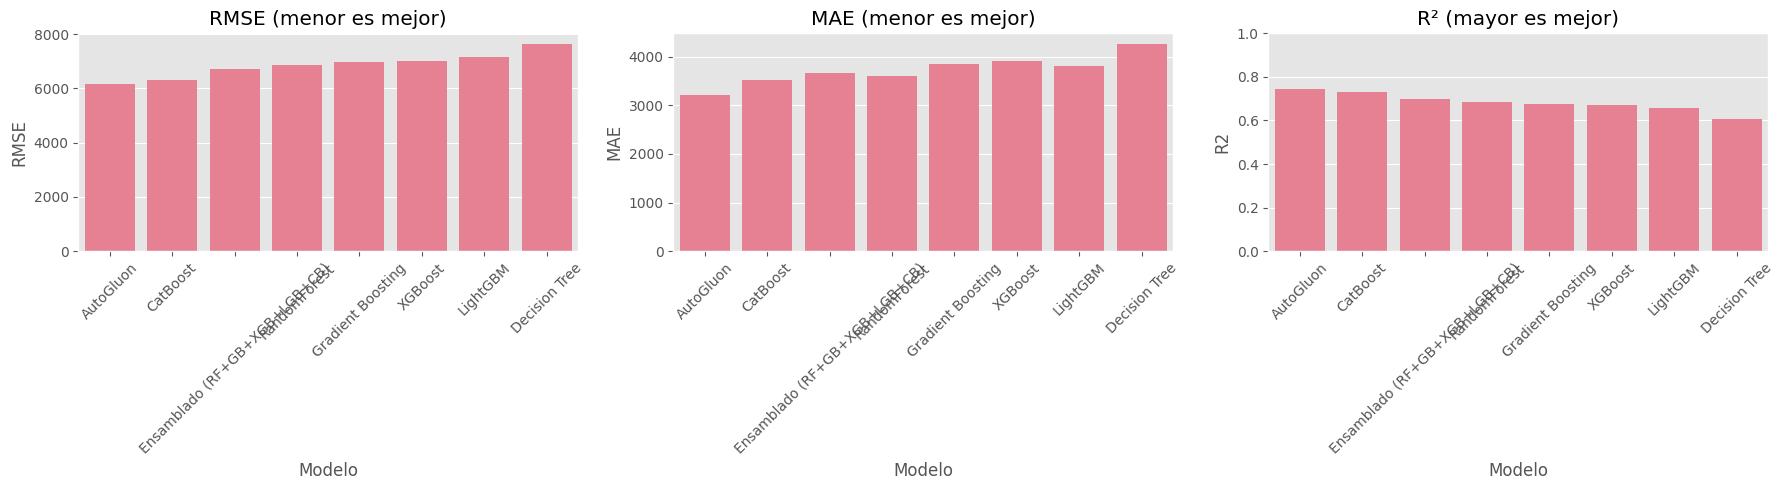

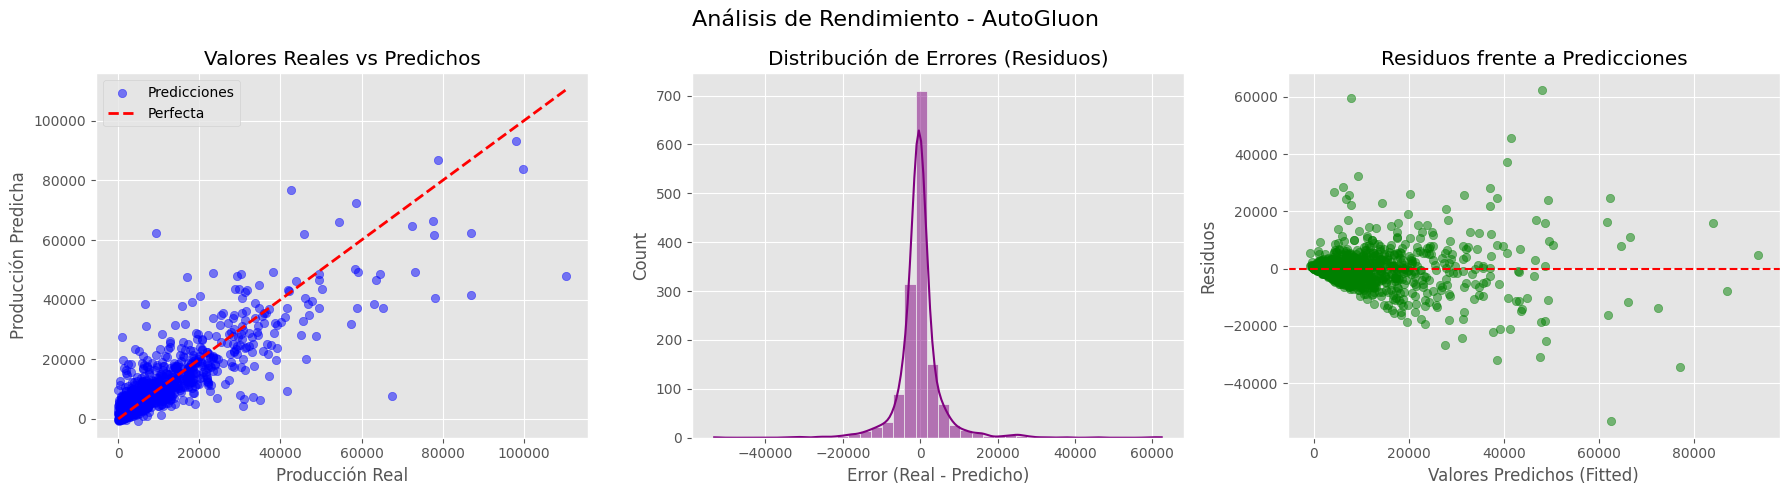

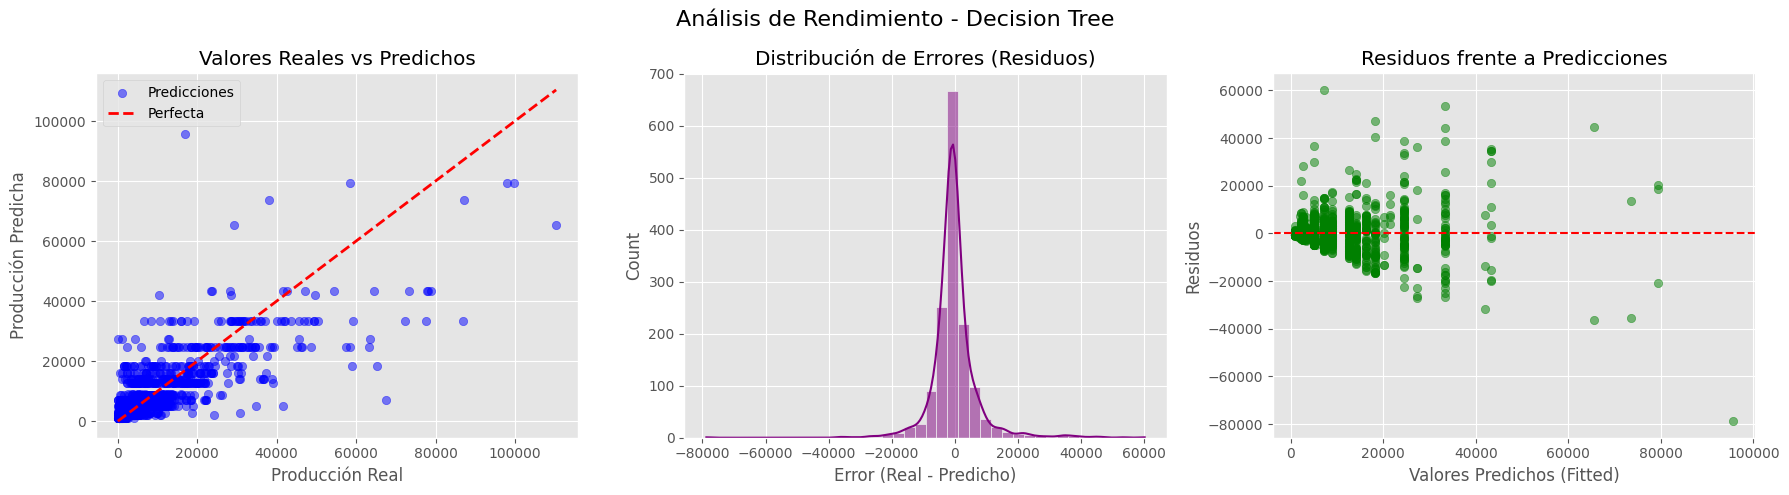

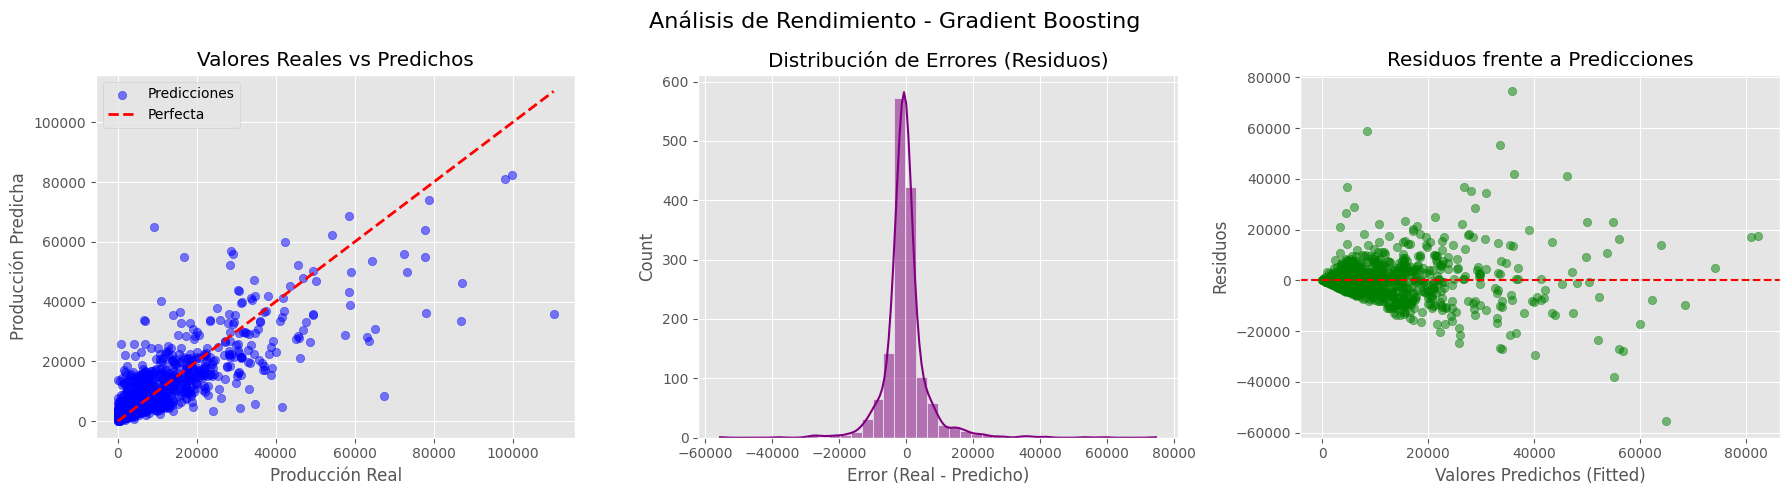

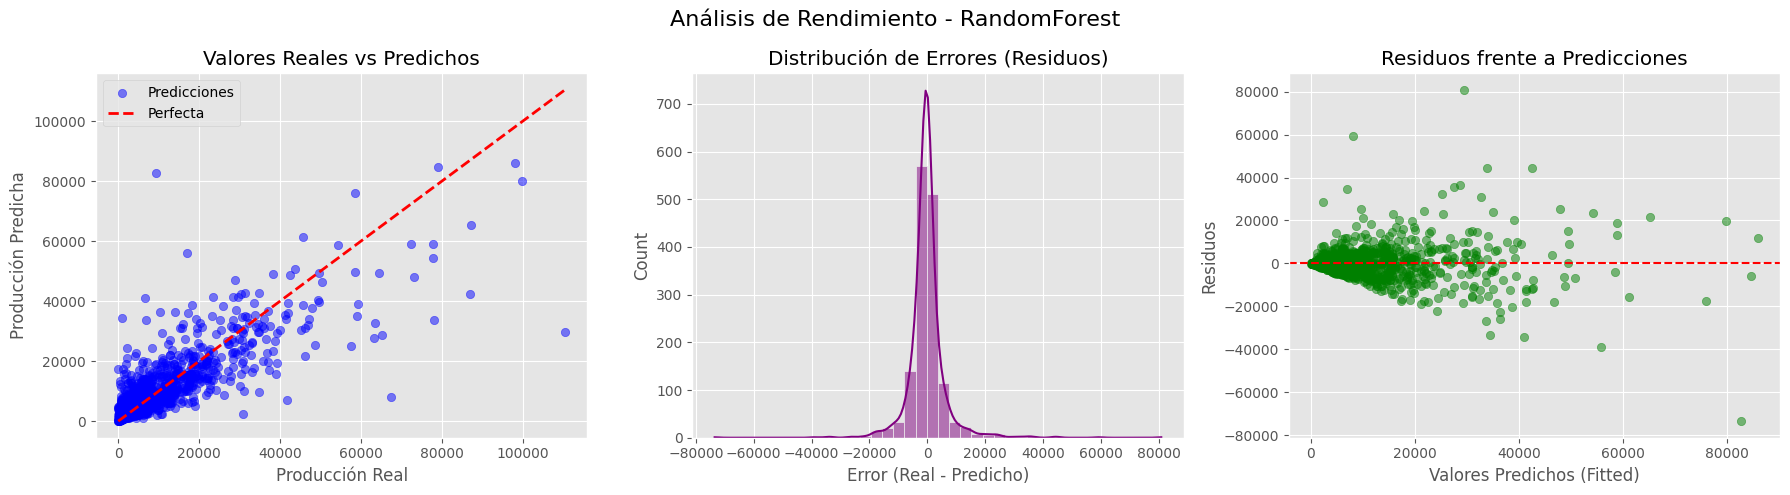

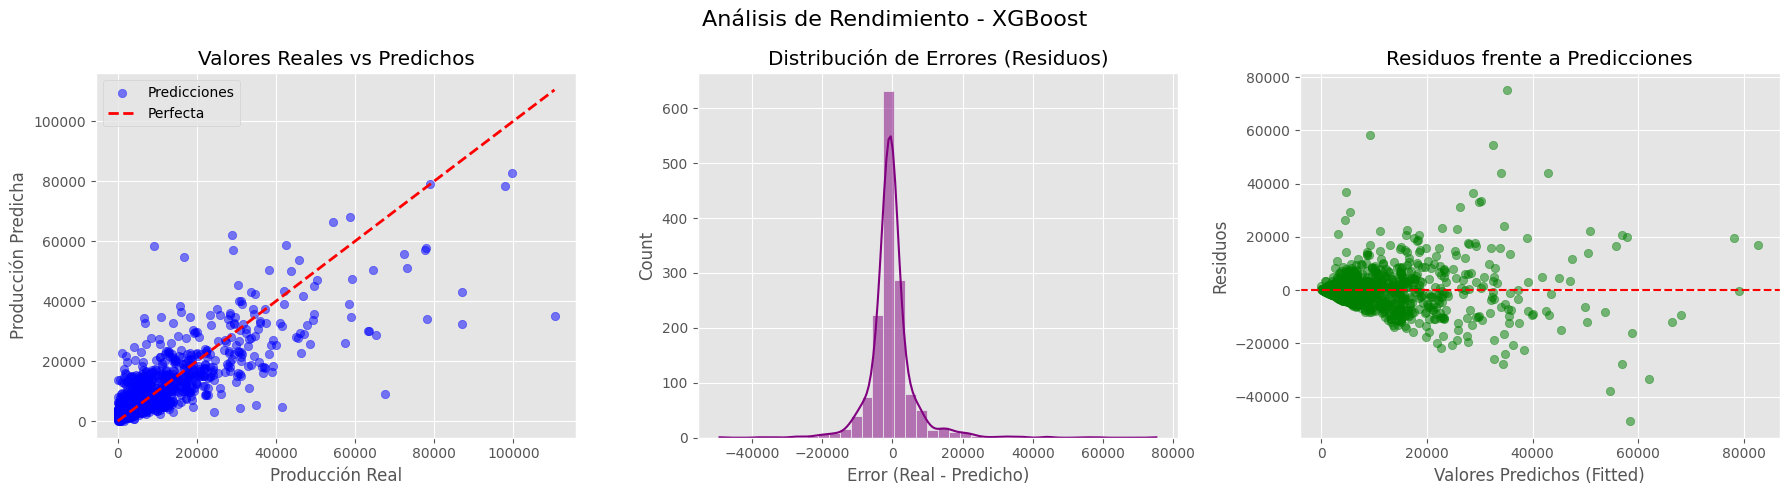

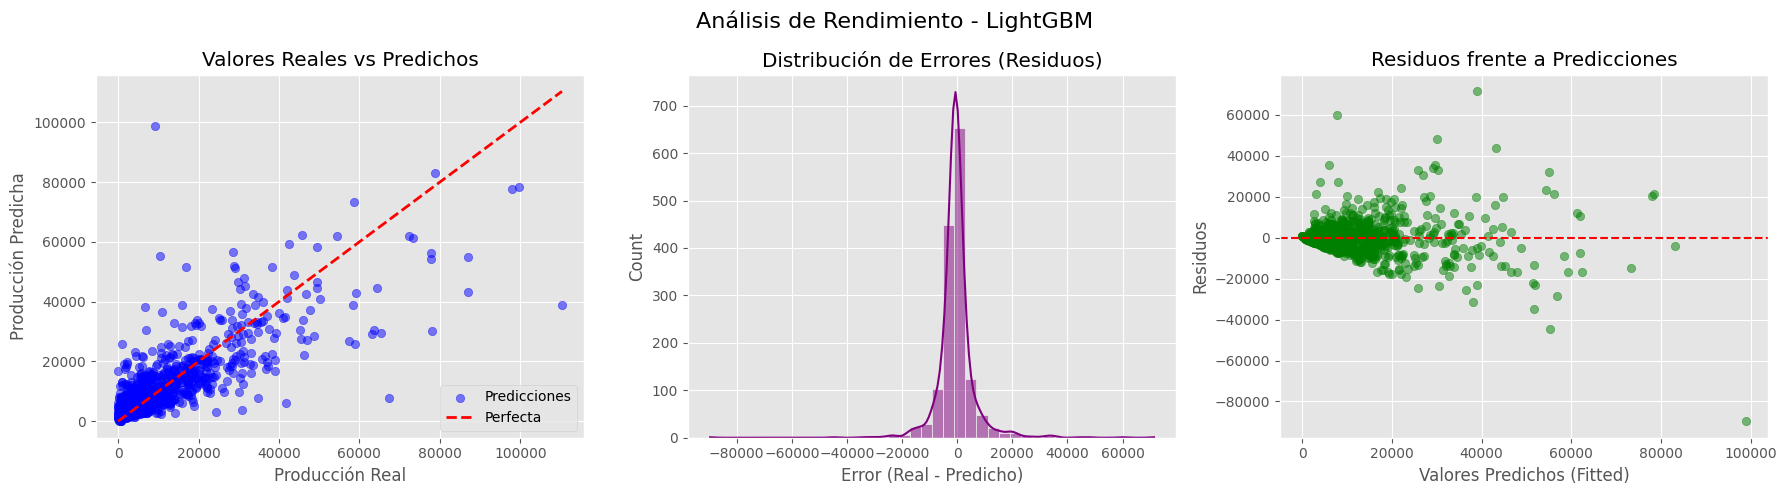

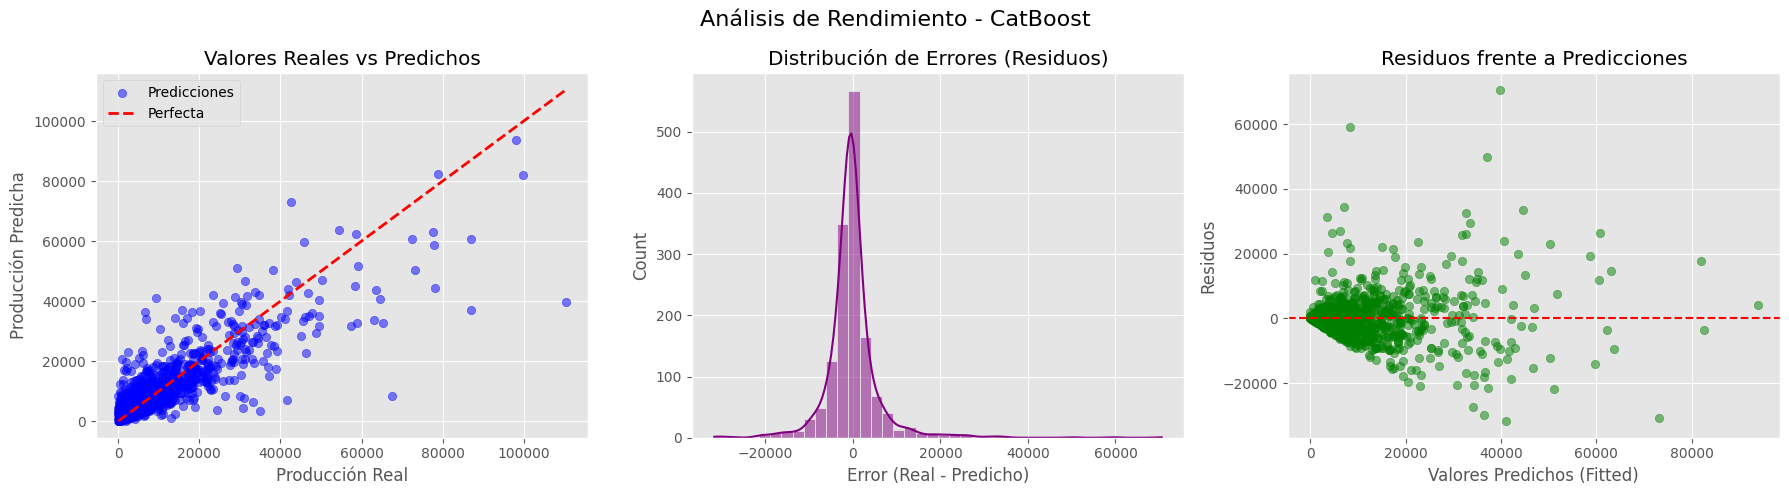

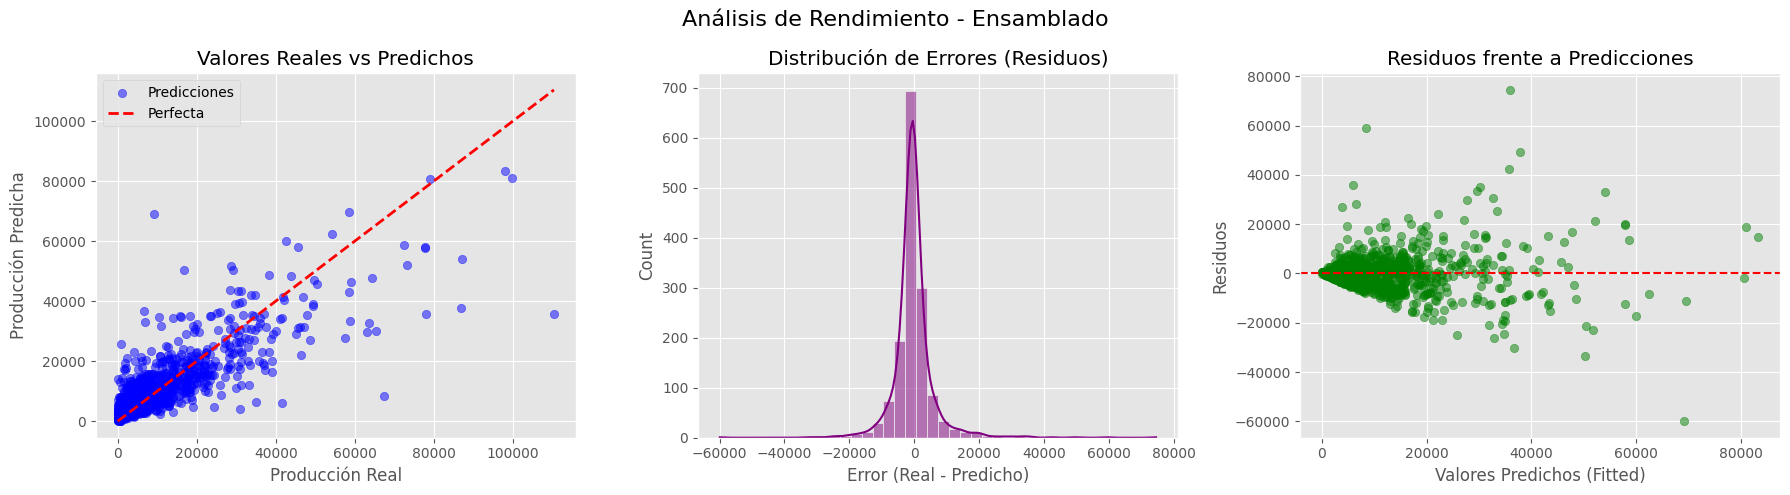

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df_resultados, x='Modelo', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE (menor es mejor)')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=df_resultados, x='Modelo', y='MAE', ax=axes[1])
axes[1].set_title('MAE (menor es mejor)')
axes[1].tick_params(axis='x', rotation=45)
sns.barplot(data=df_resultados, x='Modelo', y='R2', ax=axes[2])
axes[2].set_title('R² (mayor es mejor)')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
# --- Análisis de Residuos individual para cada modelo ---
# Bucle for para graficar los resultados de TODOS los modelos en predicciones_val
for nombre_modelo, predicciones in predicciones_val.items():
    residuos = y_val - predicciones
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # Scatter Real vs Predicha
    axes[0].scatter(y_val, predicciones, alpha=0.5, color='blue', label='Predicciones')
    axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfecta')
    axes[0].set_xlabel('Producción Real')
    axes[0].set_ylabel('Producción Predicha')
    axes[0].set_title(f'Valores Reales vs Predichos')
    axes[0].legend()
    # Histograma de Residuos
    sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color='purple')
    axes[1].set_title(f'Distribución de Errores (Residuos)')
    axes[1].set_xlabel('Error (Real - Predicho)')
    # Residuos vs Fitted
    axes[2].scatter(predicciones, residuos, alpha=0.5, color='green')
    axes[2].axhline(0, color='r', linestyle='--')
    axes[2].set_xlabel('Valores Predichos (Fitted)')
    axes[2].set_ylabel('Residuos')
    axes[2].set_title(f'Residuos frente a Predicciones')
    # Añadimos un título principal indicando qué modelo se está graficando
    plt.suptitle(f"Análisis de Rendimiento - {nombre_modelo}", fontsize=16)
    plt.tight_layout()
    plt.show()

## 8. Exportación Final (Campaña 2021)


In [11]:
print("Haciendo la predicción final de la campaña 2021 usando AutoGluon...")

# Nos aseguramos de tener un dataframe compatible con AutoGluon
df_ag_test_2021 = X_test_2021.copy()

# AutoGluon fue entrenado previamente y guardado en 'predictor' (dentro de modelos_sintonizados)
if 'AutoGluon' in modelos_sintonizados:
    ag_predictor_final = modelos_sintonizados['AutoGluon']
    # Como AutoGluon ya evaluó múltiples modelos complejos y ensamblados y guardó el mejor,
    # utilizamos ese modelo optimizado directamente.
    print("Usando el modelo AutoGluon previamente entrenado (time_limit=120s)")
    y_pred_2021 = ag_predictor_final.predict(df_ag_test_2021)
else:
    print("No se encontró AutoGluon, usando el Ensamblado (VotingRegressor)...")
    model_rf_final  = RandomForestRegressor(**search_rf.best_params_, random_state=42, n_jobs=-1)
    model_gb_final  = GradientBoostingRegressor(**search_gb.best_params_, random_state=42)
    model_xgb_final = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
    model_lgb_final = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)
    model_cb_final  = CatBoostRegressor(**search_cb.best_params_, loss_function='RMSE', random_state=42, verbose=0)

    print("Reentrenando Ensamblado en todo el histórico completo...")
    ensemble_final = VotingRegressor([
        ('rf',  model_rf_final),
        ('gb',  model_gb_final),
        ('xgb', model_xgb_final),
        ('lgb', model_lgb_final),
        ('cb',  model_cb_final),
    ])
    ensemble_final.fit(X_full, y_full)
    y_pred_2021 = ensemble_final.predict(X_test_2021)

y_pred_2021 = np.maximum(y_pred_2021, 0)

# Preparar DataFrame de respuesta
df_res = X_test_output.copy()
df_res['PRODUCCION'] = y_pred_2021

# Para asegurar el ordenamiento correcto
df_res['VARIEDAD'] = pd.to_numeric(df_res['VARIEDAD'])
df_res['MODO'] = pd.to_numeric(df_res['MODO'])
df_res['TIPO'] = pd.to_numeric(df_res['TIPO'])
df_res['COLOR'] = pd.to_numeric(df_res['COLOR'])

cols_sort = ['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']
df_res.sort_values(by=cols_sort, ascending=True, inplace=True)

df_res['PRODUCCION'] = df_res['PRODUCCION'].round(2)

print("Filas del dataframe generado:", df_res.shape[0])

# Guardar a txt sin cabecera y con separador ;
df_res.to_csv('Mi_Solucion.txt', sep=';', index=False, header=False)
print("Se ha generado Mi_Solucion.txt exitosamente.")


Haciendo la predicción final de la campaña 2021 usando AutoGluon...
Usando el modelo AutoGluon previamente entrenado (time_limit=120s)
Filas del dataframe generado: 1044
Se ha generado Mi_Solucion.txt exitosamente.
